In [1]:
import pandas as pd
import numpy as np
import scipy
import seaborn as sns
from glob import glob
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors 
import warnings
import scanpy as sc
import anndata as ad
import xarray as xr

warnings.filterwarnings("ignore")

In [2]:
sc.settings.figdir = '../figures/revision/'

In [3]:
file_prefix="test_"

In [4]:
### runs
runs=['run46']
## one condition_vec per run, named as the runs
condition_vecs={'run46':['Thpo', 'EV']}
## working samples per run , named as the runs
working_samples={'run46':list(range(0, 2))}


In [5]:
obs=pd.read_csv('../data/CODEX/intermediate_steps/seurat_object_harmony_clusts_filt_meta_bg.csv', index_col=0)
counts=scipy.io.mmread('../data/CODEX/intermediate_steps/seurat_object_harmony_clusts_filt_bg_id_counts.mtx')

In [6]:
mk_names=pd.read_csv('../data/CODEX/intermediate_steps/seurat_object_harmony_clusts_filt_bg_id_mk_names.csv', index_col=0)

In [7]:
anndata=ad.AnnData(pd.DataFrame(counts.T.todense(), columns=mk_names.x))
anndata.obs_names=obs.index

In [8]:
#### select resolution
obs.seurat_clusters=obs['SCT_snn_res.0.3']

In [9]:
obs.seurat_clusters=obs.seurat_clusters.astype('category')
obs.seurat_clusters

0_run46_EV_1          3
1_run46_EV_1          3
2_run46_EV_1          3
3_run46_EV_1          3
4_run46_EV_1          3
                     ..
12843_run46_Thpo_2    2
12844_run46_Thpo_2    0
12846_run46_Thpo_2    2
12848_run46_Thpo_2    1
12849_run46_Thpo_2    1
Name: seurat_clusters, Length: 19245, dtype: category
Categories (9, int64): [0, 1, 2, 3, ..., 5, 6, 7, 8]

In [10]:
## Name clusters
obs["seurat_clusters"] = obs["seurat_clusters"].cat.rename_categories(
    {0: "CD45+_hematopoietic_cells",
     1: 'Perivascular_myofibroblasts',
     2: 'Sinusoidal_endothelial_cells',
     3: 'Megakaryocytes',
     4: 'Erythroid_lineage',
     5: 'Myofibroblasts',
     6: 'Activated_MSCs_CAR_cells',
     7: 'Vascular_endothelial_cells',
     8: 'Pericytes',
        }
)

In [11]:
## clusters as categorical
obs.seurat_clusters=obs.seurat_clusters.cat.reorder_categories(['CD45+_hematopoietic_cells', 'Perivascular_myofibroblasts', 'Sinusoidal_endothelial_cells', 'Megakaryocytes', 
                                                            'Erythroid_lineage', 'Myofibroblasts', 'Activated_MSCs_CAR_cells', 'Vascular_endothelial_cells', 'Pericytes'])
obs.head()

,orig.ident,nCount_RNA,nFeature_RNA,condition,sample,run,nCount_SCT,nFeature_SCT,SCT_snn_res.0.2,seurat_clusters,SCT_snn_res.0.1,SCT_snn_res.0.3,SCT_snn_res.0.4,SCT_snn_res.0.5
0_run46_EV_1,CODEX_fusion_run46,3.881087,4,EV,run46_EV_1,run46,4,3,3,Megakaryocytes,2,3,4,3
1_run46_EV_1,CODEX_fusion_run46,3.935102,5,EV,run46_EV_1,run46,3,2,3,Megakaryocytes,2,3,4,3
2_run46_EV_1,CODEX_fusion_run46,3.270065,4,EV,run46_EV_1,run46,4,3,3,Megakaryocytes,2,3,4,3
3_run46_EV_1,CODEX_fusion_run46,3.283810,5,EV,run46_EV_1,run46,4,3,3,Megakaryocytes,2,3,4,3
4_run46_EV_1,CODEX_fusion_run46,3.106023,4,EV,run46_EV_1,run46,3,2,3,Megakaryocytes,2,3,4,3


In [12]:
#dat.keys()

In [13]:
#### Get coordinates
sp_coords=pd.DataFrame()
mask=pd.DataFrame()
for run in runs:
    dat = { f.split('/')[-1].split('.')[0]: xr.open_zarr(f) for f in glob('../data/CODEX/final_data/zarr/*.zarr') }
    channels=list(dat['test_Thpo'].channels.to_dataframe().index) ## test_Scan1_2 is present in all runs
    condition_vec=condition_vecs[run]

    adatas = []
    for i in working_samples[run]:
        print(i)
    
        adata=ad.AnnData(pd.DataFrame(dat[file_prefix+condition_vec[i]]._intensity, columns=channels).iloc[:,1:len(channels)])
        sp=pd.DataFrame(dat[file_prefix+condition_vec[i]]._obs).iloc[:,-2:] ## last 2 columns
        sp.columns=['0', '1']
        sp.index=adata.obs.index
        adata.obsm['spatial']=sp.to_numpy()

        ## Add seg mask
        adata.obs['mask']=list(pd.DataFrame(dat[file_prefix+condition_vec[i]]._obs)[0])
        
        print(adata.obs.shape)
        
        adata.obs_names=[n+'_'+run+'_'+condition_vec[i]+'_'+str(np.abs(i-2)) for n in adata.obs_names]
        
        adata=adata[obs.index[obs['sample']==run+'_'+condition_vec[i]+'_'+str(np.abs(i-2))]]
        adatas.append(adata)

    ad_run=ad.concat(adatas)
    sp_coords=pd.concat([sp_coords, pd.DataFrame(ad_run.obsm['spatial'])])
    sp_coords.index=ad_run.obs_names
    mask=pd.concat([mask, ad_run.obs])
    mask.index=ad_run.obs_names
sp_coords=sp_coords.loc[obs.index]
mask=mask.loc[obs.index]

0
(12850, 1)
1
(11424, 1)


In [14]:
anndata=anndata[obs.index]

In [15]:
anndata.obs=obs

In [16]:
anndata.obs['mask']=mask

In [17]:
anndata.obsm['spatial']=sp_coords[[0,1]].to_numpy()

In [18]:
anndata.obs.head()

,orig.ident,nCount_RNA,nFeature_RNA,condition,sample,run,nCount_SCT,nFeature_SCT,SCT_snn_res.0.2,seurat_clusters,SCT_snn_res.0.1,SCT_snn_res.0.3,SCT_snn_res.0.4,SCT_snn_res.0.5,mask
0_run46_EV_1,CODEX_fusion_run46,3.881087,4,EV,run46_EV_1,run46,4,3,3,Megakaryocytes,2,3,4,3,1.0
1_run46_EV_1,CODEX_fusion_run46,3.935102,5,EV,run46_EV_1,run46,3,2,3,Megakaryocytes,2,3,4,3,1.0
2_run46_EV_1,CODEX_fusion_run46,3.270065,4,EV,run46_EV_1,run46,4,3,3,Megakaryocytes,2,3,4,3,1.0
3_run46_EV_1,CODEX_fusion_run46,3.283810,5,EV,run46_EV_1,run46,4,3,3,Megakaryocytes,2,3,4,3,1.0
4_run46_EV_1,CODEX_fusion_run46,3.106023,4,EV,run46_EV_1,run46,3,2,3,Megakaryocytes,2,3,4,3,1.0


In [19]:
anndata.var_names

Index(['X33.CD45', 'X80.Sca1', 'X38.Ter119', 'X32.CD31', 'X149.Endomucin',
       'X11.aSMA', 'X40.Podoplanin', 'X84.NCAM', 'X82.Vimentin', 'X51.CD146',
       'Osteopontin.166', 'X29.CD106', 'X158.VE.Cadherin', 'X127.CD61',
       'X103.CXCL12', 'CD71.133', 'Col1a.19'],
      dtype='str', name='x')

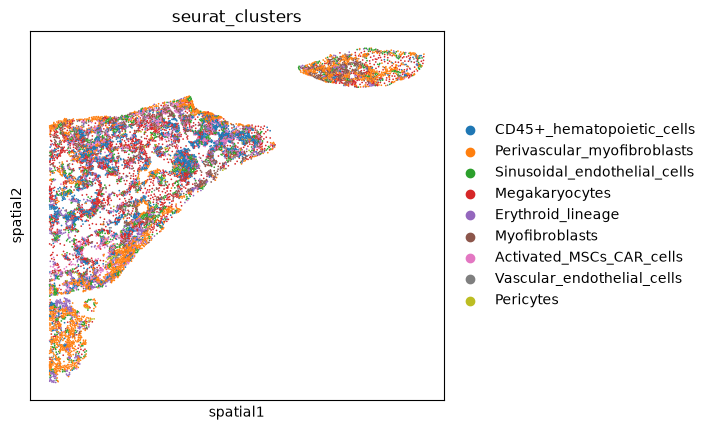

In [20]:
ad=anndata[anndata.obs['sample']=='run46_Thpo_2']
sc.pl.spatial(ad, color='seurat_clusters', spot_size = 20, use_raw=False)

In [21]:
## Assign colors
clist=ad.uns['seurat_clusters_colors']

In [22]:
anndata.obs['clusters_named']=anndata.obs['seurat_clusters']

In [23]:
anndata.obs['clusters_named']=anndata.obs.clusters_named.astype('category')
anndata.obs.clusters_named.cat.categories

Index(['CD45+_hematopoietic_cells', 'Perivascular_myofibroblasts',
       'Sinusoidal_endothelial_cells', 'Megakaryocytes', 'Erythroid_lineage',
       'Myofibroblasts', 'Activated_MSCs_CAR_cells',
       'Vascular_endothelial_cells', 'Pericytes'],
      dtype='str')

In [24]:
anndata.uns['clusters_named_colors']=clist

In [25]:
ad2=sc.read_h5ad('../data/CODEX/intermediate_steps/seurat_object_harmony_clusts_filt_bg_id.h5ad')

anndata.obsm['X_harmony']=ad2.obsm['X_harmony']
anndata.obsm['X_pca']=ad2.obsm['X_pca']
anndata.obsm['X_umap']=ad2.obsm['X_umap']

del ad2

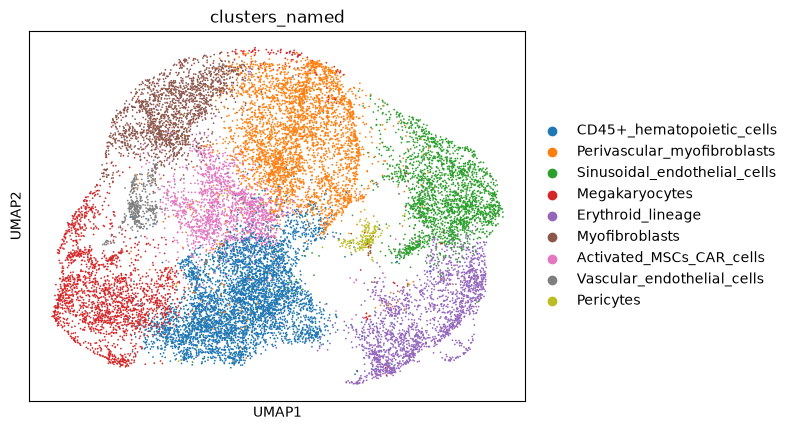

In [26]:
sc.pl.umap(anndata, color='clusters_named')

In [27]:
#### Spp1+ clusters

In [28]:
# 1. Define threshold
qthr = 0.9

# 2. Calculate the expression cutoff value from your feature
cutoff = np.quantile(anndata.to_df()["Osteopontin.166"], q=qthr)

# 3. Create the initial column with default values
anndata.obs["Spp1_pos"] = "Negative"

# 4. Find cell names that pass the threshold
pos_cells = anndata.to_df().index[anndata.to_df()["Osteopontin.166"] >= cutoff]

# 5. Safely update only those cells using .loc
anndata.obs.loc[pos_cells, "Spp1_pos"] = "Spp1+"

In [29]:
### Spp1 positive proportions per cluster

In [30]:
clist=['blue', 'red']

<Axes: xlabel='clusters_named'>

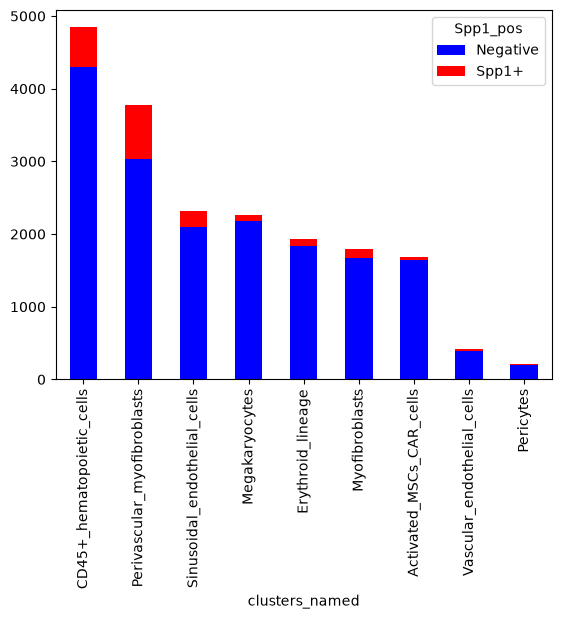

In [31]:
clusts_in_smpls=anndata.obs.groupby(['clusters_named', 'Spp1_pos']).size().unstack()
clust_cols=pd.Series(clist, index=clusts_in_smpls.columns)
clusts_in_smpls.plot.bar(stacked=True, color=clust_cols)

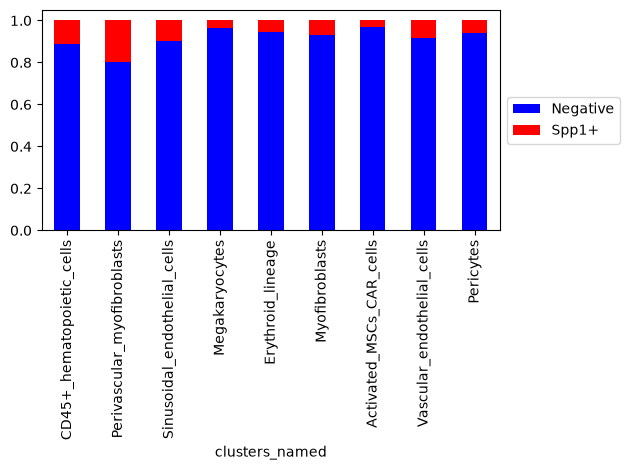

In [32]:
clusts_in_smpls_norm=clusts_in_smpls.T/clusts_in_smpls.T.sum()
clusts_in_smpls_norm.T.plot.bar(stacked=True, color=clust_cols)
plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.tight_layout()

In [33]:
list(clusts_in_smpls_norm.columns[clusts_in_smpls_norm.loc['Spp1+']>0.09])

['CD45+_hematopoietic_cells',
 'Perivascular_myofibroblasts',
 'Sinusoidal_endothelial_cells']

In [34]:
anndata.uns['clusters_named_colors']

['#1f77b4',
 '#ff7f0e',
 '#2ca02c',
 '#d62728',
 '#9467bd',
 '#8c564b',
 '#e377c2',
 '#7f7f7f',
 '#bcbd22']

In [35]:
# Define conditions
cond_immune = (anndata.obs["clusters_named"] == "CD45+_hematopoietic_cells") & (
    anndata.obs["Spp1_pos"] == "Spp1+"
)
cond_myo = (anndata.obs["clusters_named"] == "Perivascular_myofibroblasts") & (
    anndata.obs["Spp1_pos"] == "Spp1+"
)
cond_endo = (anndata.obs["clusters_named"] == "Sinusoidal_endothelial_cells") & (
    anndata.obs["Spp1_pos"] == "Spp1+"
)

# Put them in a list matching your desired new names
conditions = [cond_immune, cond_myo, cond_endo]
choices = ["Spp1+_Immune", "Spp1+_Osteolineage_cells", "Spp1+_Sinusoidal_pericytes"]

# Update the column safely (keeping old names if no condition is met)
anndata.obs["clusters_named"] = np.select(
    conditions, choices, default=anndata.obs["clusters_named"]
)

# Optional: Convert it back to categorical for Scanpy plotting optimization
anndata.obs["clusters_named"] = anndata.obs["clusters_named"].astype("category")

In [36]:
anndata.obs.clusters_named.cat.categories

Index(['Activated_MSCs_CAR_cells', 'CD45+_hematopoietic_cells',
       'Erythroid_lineage', 'Megakaryocytes', 'Myofibroblasts', 'Pericytes',
       'Perivascular_myofibroblasts', 'Sinusoidal_endothelial_cells',
       'Spp1+_Immune', 'Spp1+_Osteolineage_cells',
       'Spp1+_Sinusoidal_pericytes', 'Vascular_endothelial_cells'],
      dtype='str')

In [37]:
anndata.obs.clusters_named=anndata.obs.clusters_named.cat.reorder_categories(['CD45+_hematopoietic_cells', 'Perivascular_myofibroblasts', 'Sinusoidal_endothelial_cells', 'Megakaryocytes', 
                                                            'Erythroid_lineage', 'Myofibroblasts', 'Activated_MSCs_CAR_cells', 'Vascular_endothelial_cells', 'Pericytes','Spp1+_Sinusoidal_pericytes', 'Spp1+_Immune',
                                                            'Spp1+_Osteolineage_cells'])


In [38]:
clist=['#1f77b4',
 '#ff7f0e',
 '#2ca02c',
 '#d62728',
 '#9467bd',
 '#8c564b',
 '#b1fc67',
 '#7f7f7f',
 '#bcbd22',
 '#f4b2db',
 '#e377c2',
 '#9e3b7e'
      ]

In [39]:
anndata.uns['clusters_named_colors']=clist

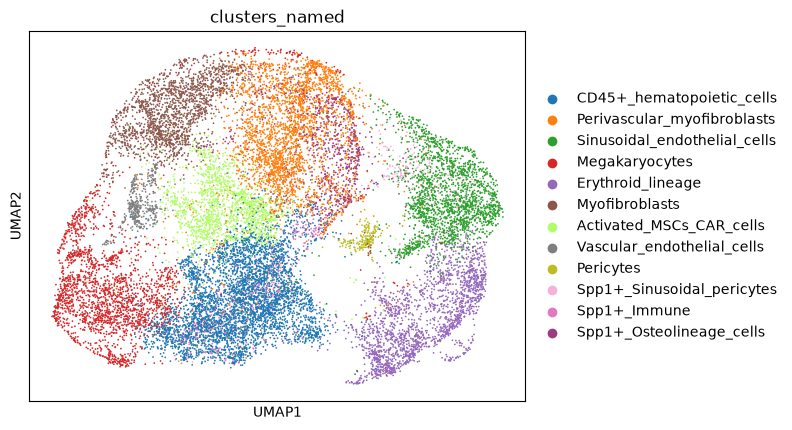

In [40]:
sc.pl.umap(anndata, color='clusters_named', save='Spp1_clusts_UMAP_final.pdf')

In [41]:
np.quantile(anndata.to_df()['Osteopontin.166'], q=qthr)

np.float64(0.5376757654610957)

<Axes: xlabel='sample'>

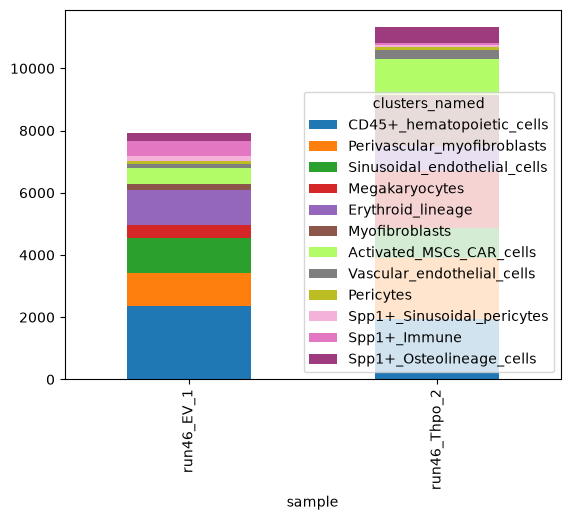

In [42]:
clusts_in_smpls=anndata.obs.groupby(['sample', 'clusters_named']).size().unstack()
clust_cols=pd.Series(clist, index=clusts_in_smpls.columns)
clusts_in_smpls.plot.bar(stacked=True, color=clust_cols)

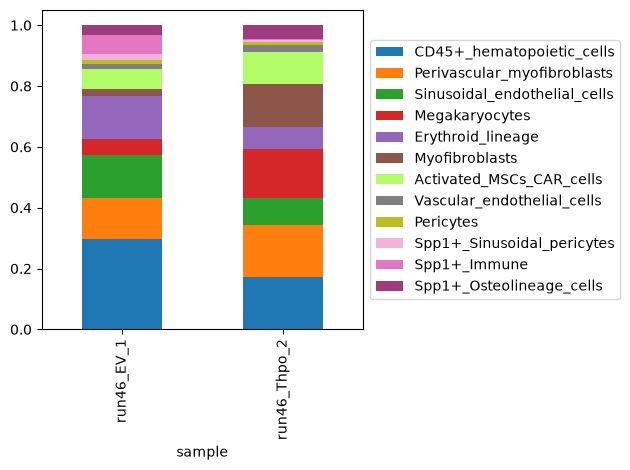

In [43]:
clusts_in_smpls_norm=clusts_in_smpls.T/clusts_in_smpls.T.sum()
clusts_in_smpls_norm.T.plot.bar(stacked=True, color=clust_cols)
plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.tight_layout()

In [44]:
anndata.obs.clusters_named.value_counts()

clusters_named
CD45+_hematopoietic_cells       4296
Perivascular_myofibroblasts     3026
Megakaryocytes                  2257
Sinusoidal_endothelial_cells    2093
Erythroid_lineage               1938
Myofibroblasts                  1797
Activated_MSCs_CAR_cells        1686
Spp1+_Osteolineage_cells         753
Spp1+_Immune                     548
Vascular_endothelial_cells       420
Spp1+_Sinusoidal_pericytes       223
Pericytes                        208
Name: count, dtype: int64

<Axes: xlabel='condition'>

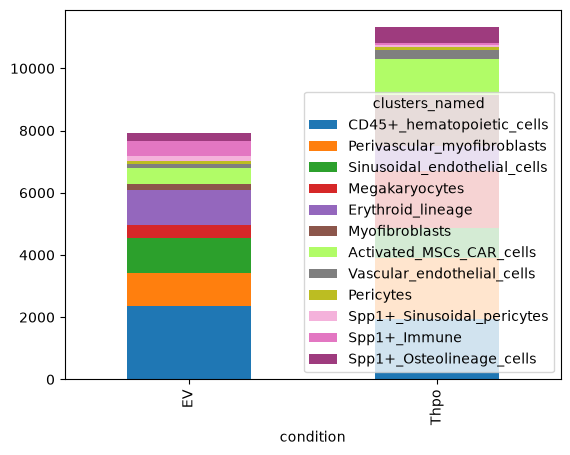

In [45]:
clusts_in_smpls=anndata.obs.groupby(['condition', 'clusters_named']).size().unstack()
clust_cols=pd.Series(clist, index=clusts_in_smpls.columns)
clusts_in_smpls.plot.bar(stacked=True, color=clust_cols)

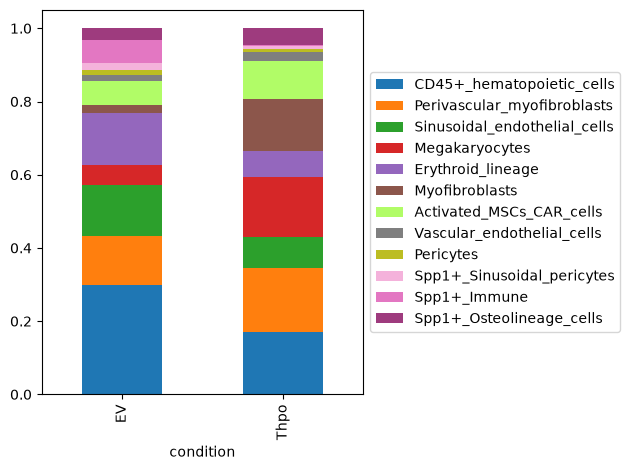

In [46]:
clusts_in_smpls_norm=clusts_in_smpls.T/clusts_in_smpls.T.sum()
clusts_in_smpls_norm.T.plot.bar(stacked=True, color=clust_cols)
plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.tight_layout()
plt.savefig('../figures/revision/clusts_in_conditions_r0.3_v2.pdf')

In [47]:
clusts_in_smpls_norm.columns=clusts_in_smpls_norm.columns.astype('category')
clusts_in_smpls_norm.columns=clusts_in_smpls_norm.columns.reorder_categories(['EV', 'Thpo'])

In [48]:
clusts_in_smpls_norm = clusts_in_smpls_norm.sort_index(axis=1)
clusts_in_smpls_norm = clusts_in_smpls_norm.sort_index(axis=0, ascending=False)

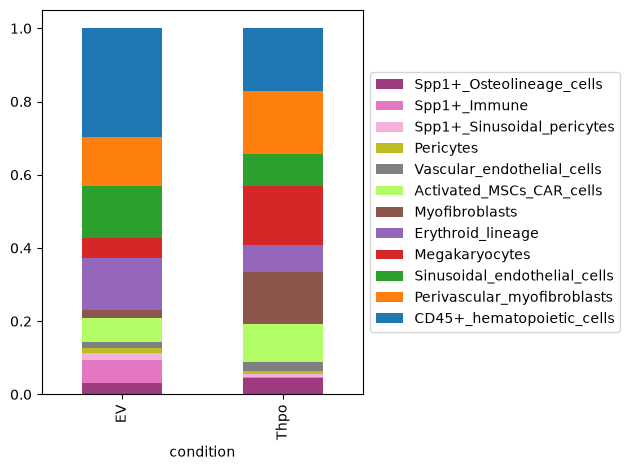

In [49]:
clusts_in_smpls_norm.T.plot.bar(stacked=True, color=clust_cols[clusts_in_smpls_norm.index])
plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.tight_layout()
plt.savefig('../figures/revision/clusts_in_conditions_ordered.pdf')

In [50]:
### MK mask check

<Axes: xlabel='mask'>

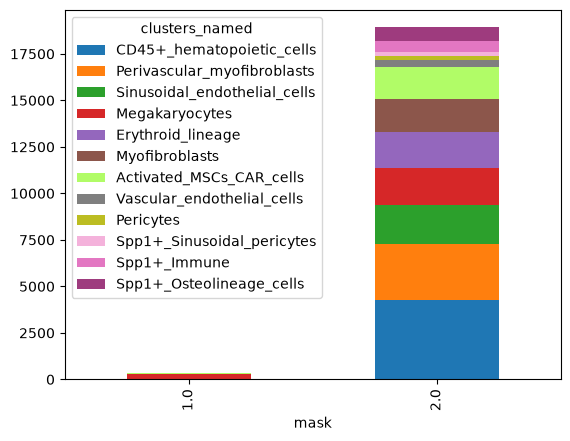

In [51]:
clusts_in_smpls=anndata.obs.groupby(['mask', 'clusters_named']).size().unstack()
clust_cols=pd.Series(clist, index=clusts_in_smpls.columns)
clusts_in_smpls.plot.bar(stacked=True, color=clust_cols)

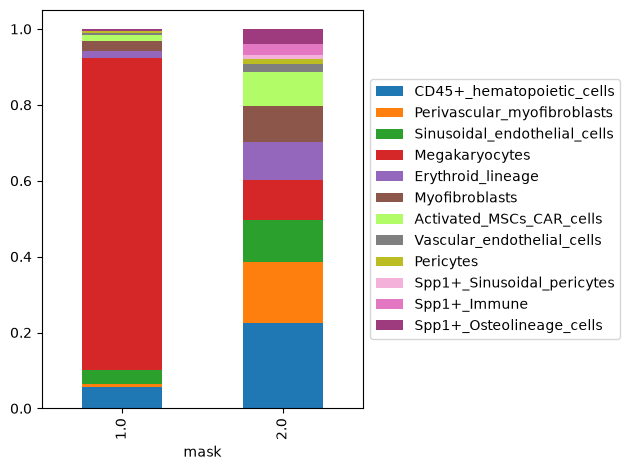

In [52]:
clusts_in_smpls_norm=clusts_in_smpls.T/clusts_in_smpls.T.sum()
clusts_in_smpls_norm.T.plot.bar(stacked=True, color=clust_cols)
plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.tight_layout()


In [53]:
anndata.obs.rename(columns={"Unnamed: 0": "cell_id", "nCount_RNA":"total_arcsinh_intensity_bgFilt", "nCount_SCT":"total_arcsinh_intensity_bgFilt_SCT",
                           "nFeature_RNA":"nFeature"}, inplace=True)

In [54]:
anndata.write_h5ad('../data/CODEX/final_data/CODEX_run45_anndata_final.h5ad')

In [55]:
anndata.obs

,orig.ident,total_arcsinh_intensity_bgFilt,nFeature,condition,sample,run,total_arcsinh_intensity_bgFilt_SCT,nFeature_SCT,SCT_snn_res.0.2,seurat_clusters,SCT_snn_res.0.1,SCT_snn_res.0.3,SCT_snn_res.0.4,SCT_snn_res.0.5,mask,clusters_named,Spp1_pos
0_run46_EV_1,CODEX_fusion_run46,3.881087,4,EV,run46_EV_1,run46,4,3,3,Megakaryocytes,2,3,4,3,1.0,Megakaryocytes,Spp1+
1_run46_EV_1,CODEX_fusion_run46,3.935102,5,EV,run46_EV_1,run46,3,2,3,Megakaryocytes,2,3,4,3,1.0,Megakaryocytes,Negative
2_run46_EV_1,CODEX_fusion_run46,3.270065,4,EV,run46_EV_1,run46,4,3,3,Megakaryocytes,2,3,4,3,1.0,Megakaryocytes,Negative
3_run46_EV_1,CODEX_fusion_run46,3.283810,5,EV,run46_EV_1,run46,4,3,3,Megakaryocytes,2,3,4,3,1.0,Megakaryocytes,Spp1+
4_run46_EV_1,CODEX_fusion_run46,3.106023,4,EV,run46_EV_1,run46,3,2,3,Megakaryocytes,2,3,4,3,1.0,Megakaryocytes,Negative
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12843_run46_Thpo_2,CODEX_fusion_run46,2.941232,13,Thpo,run46_Thpo_2,run46,2,2,2,Sinusoidal_endothelial_cells,1,2,2,2,2.0,Sinusoidal_endothelial_cells,Negative
12844_run46_Thpo_2,CODEX_fusion_run46,1.881641,6,Thpo,run46_Thpo_2,run46,4,4,1,CD45+_hematopoietic_cells,0,0,6,6,2.0,CD45+_hematopoietic_cells,Negative
12846_run46_Thpo_2,CODEX_fusion_run46,1.139374,4,Thpo,run46_Thpo_2,run46,2,1,2,Sinusoidal_endothelial_cells,1,2,2,2,2.0,Sinusoidal_endothelial_cells,Negative
12848_run46_Thpo_2,CODEX_fusion_run46,7.014114,14,Thpo,run46_Thpo_2,run46,2,2,1,Perivascular_myofibroblasts,0,1,1,7,2.0,Spp1+_Osteolineage_cells,Spp1+


## README

CODEX protein intensity data from **3 runs** (run27 - 29) , in total **13 samples** in **3 different conditions** , was stored in an anndata object: https://anndata.readthedocs.io/en/latest/tutorials/notebooks/getting-started.html 

The 'X' slot (anndata.X) contains normalized filtered intensities per protein per cell

The obsm['spatial'] slot (anndata.obsm['spatial']) contains the cells coordinates in each slice

The 'obs' slot contains information about each cell (rows) in each column:

    'arcsinh_intensity_bgFilt' = sum of arcsinh transformed protein intensities 
    
    'nFeature' = number of features detected before SCT transformation
    
    'arcsinh_intensity_bgFilt_SCT' = sum of SCT normalized arcsinh transformed protein intensities
    
    'nFeature_SCT' = number of features detected after SCT transformation
    
    'SCT_snn_res.0.2'= clusters at 0.2 resolution

    ...
    
    'SCT_snn_res.0.5' = clusters at 0.5 resolution
    
    'seurat_clusters' = annotated clusters at 0.4 resolution
    
    'clusters_named' = annotated clusters at 0.4 resolution
    